TASK 3: Real-world data aquisition and handling

In [12]:
from datetime import datetime

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import scipy
from matplotlib.ticker import MaxNLocator
from datetime import timedelta

# Import Pandas only for reading Watch CSV File and for plotting description in Q1
import pandas as pd


In [13]:
def load_bp_csv(filename, start_datetime):
    test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
    test = test.drop(0)
    test = test.drop(test.columns[3], axis=1)  # Drop the first column
    test = test.rename(columns={'CH9': 'ecg', 'CH1': 'ppg'})
    test['ppg'] = pd.to_numeric(test['ppg'], errors='coerce')
    # if 'min' in test.columns, create new milli sec column
    if 'min' in test.columns:
        # Convert 'min' to milliseconds
        test['time_ms'] = test['min'] * 60 * 1000
    else:
        test = test.rename(columns={'milliSec': 'time_ms'})
    test['ecg'] = pd.to_numeric(test['ecg'], errors='coerce')
    test['timestamp'] = pd.to_datetime(start_datetime) + pd.to_timedelta(test['time_ms'], unit='ms')
    return test


def load_watch_ecg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['Timestamp', 'ECG data']].dropna()
    df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ecg'] = pd.to_numeric(df['ecg'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_ms'] = (df['timestamp'] - df['timestamp'].iloc[0])
    return df


def load_watch_data(ecg_file, ppg_file):
    ecg_df = pd.read_csv(ecg_file, skiprows=2)
    ppg_df = pd.read_csv(ppg_file, skiprows=2)

    # Rename columns for clarity
    ecg_df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    ppg_df.rename(columns={'PPG Timestamp': 'timestamp', 'PPG data': 'ppg'}, inplace=True)

    latest_start_time = max(ecg_df['timestamp'].iloc[0], ppg_df['timestamp'].iloc[0])
    earliest_end_time = min(ecg_df['timestamp'].iloc[-1], ppg_df['timestamp'].iloc[-1])

    # Filter data to the common time range
    ecg_df = ecg_df[(ecg_df['timestamp'] >= latest_start_time) & (ecg_df['timestamp'] <= earliest_end_time)]
    ppg_df = ppg_df[(ppg_df['timestamp'] >= latest_start_time) & (ppg_df['timestamp'] <= earliest_end_time)]

    # Drop all columns except timestamp, time_ms and ecg/ppg
    ppg_df = ppg_df.drop(columns=['ADXL Timestamp'])
    ecg_df = ecg_df.drop(columns=['Seq No.'])
    # Merge ECG and PPG based on the millisecond given
    merged_df = pd.merge_asof(ecg_df.sort_values('timestamp'), ppg_df.sort_values('timestamp'), on='timestamp',
                              direction='nearest')

    merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], unit='ms')
    return merged_df


def plot_watch_bp_ecg(watch_df, bp_data, start_time, end_time, dataset_name='Recording'):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    watch_df.sort_values('timestamp', inplace=True)
    bp_data.sort_values('time_ms', inplace=True)

    # Select time frame to plot
    # Discard time frames that are not represented in both recordings
    latest_start_time = max(watch_df['timestamp'].iloc[0], bp_data['timestamp'].iloc[0]) # + timedelta(minutes=5)
    earliest_end_time = min(watch_df['timestamp'].iloc[-1], bp_data['timestamp'].iloc[-1])
    watch_df = watch_df[(watch_df['timestamp'] >= latest_start_time) & (watch_df['timestamp'] <= earliest_end_time)]
    watch_df = watch_df[(watch_df['timestamp'] >= start_time) & (watch_df['timestamp'] <= end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= latest_start_time) & (bp_data['timestamp'] <= earliest_end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= start_time) & (bp_data['timestamp'] <= end_time)]
    watch_df = watch_df.dropna()
    # Plot ECG from Watch
    ax1.plot(watch_df['timestamp'], watch_df['PPG'], label='PPG from Watch', color='blue')
    ax1.set_ylabel('ECG Amplitude')
    ax1.set_xlabel('Time')
    ax1.set_title(f'{dataset_name} - PPG Signal from Smartwatch')
    ax1.legend()

    # Plot ECG from BioPac
    ax2.plot(bp_data['timestamp'], bp_data['ecg'], label='ECG from BioPac', color='orange')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('ECG Amplitude')
    ax2.set_title(f'{dataset_name} - ECG Signal from BioPac')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    bp_data['ppg']
    fig, ax3 = plt.subplots(figsize=(12, 4))
    ax3.plot(bp_data['timestamp'], bp_data['ppg'], label='PPG from BioPac', color='orange')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('ECG Amplitude')
    ax3.set_title(f'{dataset_name} - PPG Signal from BioPac')
    ax3.legend()
    ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.tight_layout()
    plt.show()
    # plot xyz in one plot
    fig, ax4 = plt.subplots(figsize=(12, 4))
    ax4.plot(watch_df['timestamp'],watch_df['X'], label='X-axis', color='red')
    ax4.plot(watch_df['timestamp'], watch_df['Y'], label='Y-axis', color='green')
    ax4.plot(watch_df['timestamp'], watch_df['Z'], label='Z-axis', color='purple')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Acceleration')
    ax4.set_title(f'{dataset_name} - Acceleration Data from Watch')
    ax4.legend()
    plt.tight_layout()
    plt.show()


def crop_window(data, start_time, end_time):
    data = data[(data['timestamp'] >= start_time) & (data['timestamp'] <= end_time)]
    return data

In [14]:
watch_rest = load_watch_data('data/assignment_3/Rest/ecg_2025_06_12_12_57_44ecgcentrifuge.csv',
                               'data/assignment_3/Rest/ppg_2025_06_12_12_57_44ppgcentrifuge.csv')
#2025-06-12 12:42:40.750
bp_rest = load_bp_csv('data/assignment_3/Rest/Biopac.txt',
                        start_datetime=datetime(2025, 6, 12, 10, 58, 20, 193000) - timedelta(seconds=.8))

watch_stairs = load_watch_data('data/assignment_3/Stairs/ecg_2025_06_12_12_00_41ecgcentrifuge.csv',
                               'data/assignment_3/Stairs/ppg_2025_06_12_12_00_41ppgcentrifuge.csv')
#2025-06-12 12:01:19.122
bp_stairs = load_bp_csv('data/assignment_3/Stairs/Biopac.txt',
                        start_datetime=datetime(2025, 6, 12, 10, 1, 3, 334000 ) - timedelta(seconds=.8))

watch_workout = load_watch_data('data/assignment_3/Workout/ecg_2025_06_12_12_42_06ecgcentrifuge.csv',
                                 'data/assignment_3/Workout/ppg_2025_06_12_12_42_06ppgcentrifuge.csv')
#2025-06-12 12:42:40.750
bp_workout = load_bp_csv('data/assignment_3/Workout/Biopac.txt',
                          start_datetime=datetime(2025, 6, 12, 10, 42, 40, 750000) - timedelta(seconds=.4))




C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\4255193106.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\4255193106.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\4255193106.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')


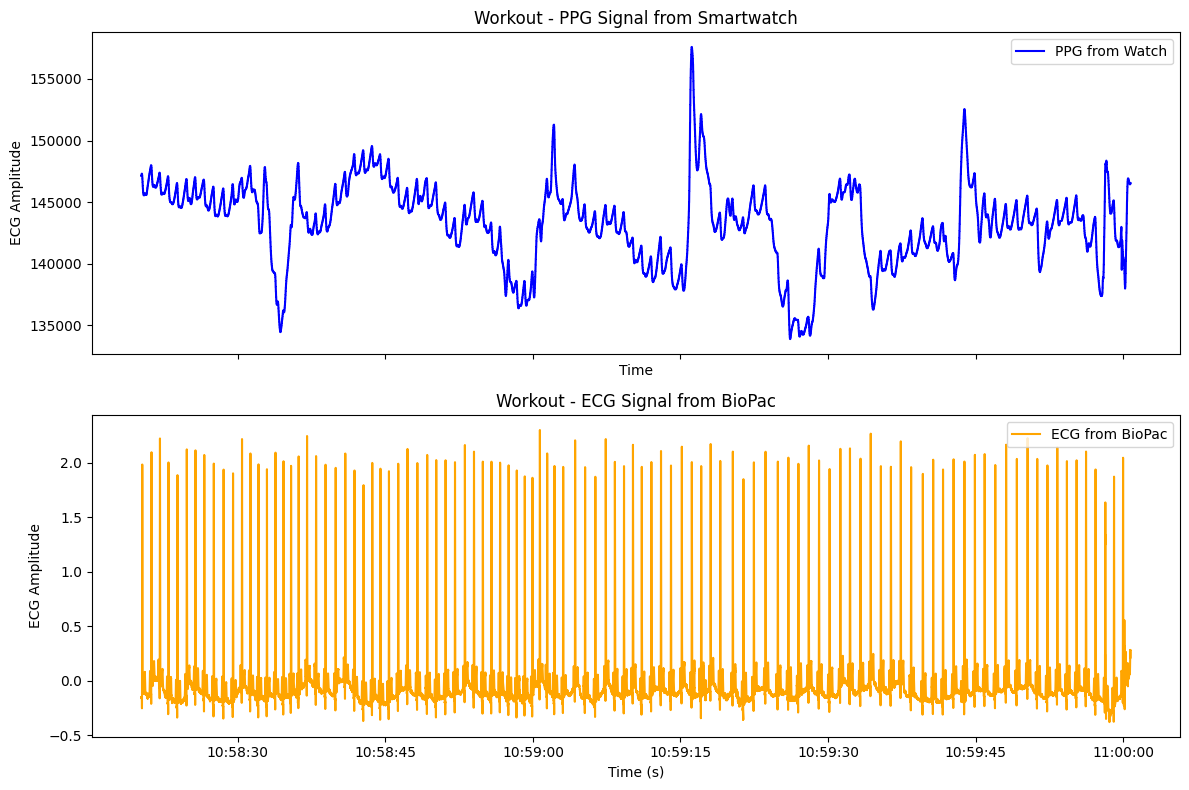

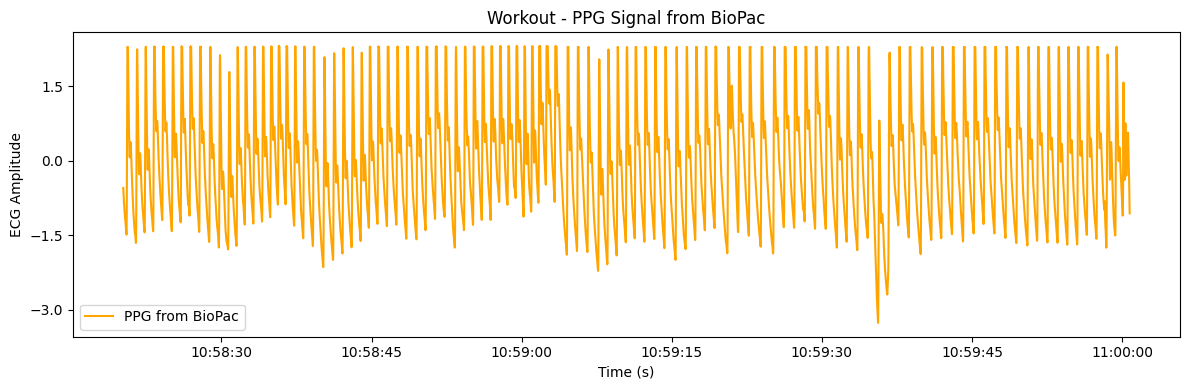

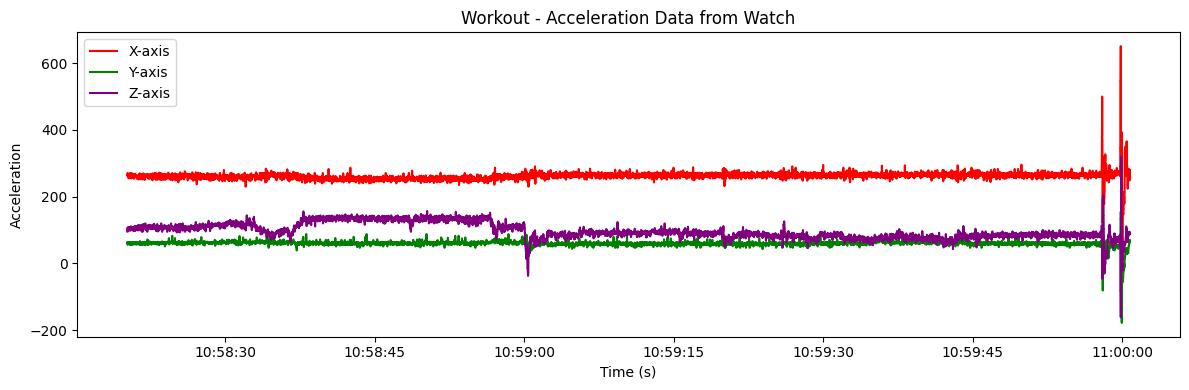

In [15]:
plot_watch_bp_ecg(watch_rest, bp_rest,
                  start_time=datetime(2025, 6, 12, 10, 58, 20, 193000),
                  end_time=datetime(2025, 6, 12, 11,0, 0 , 750000) ,
                  dataset_name='Workout')

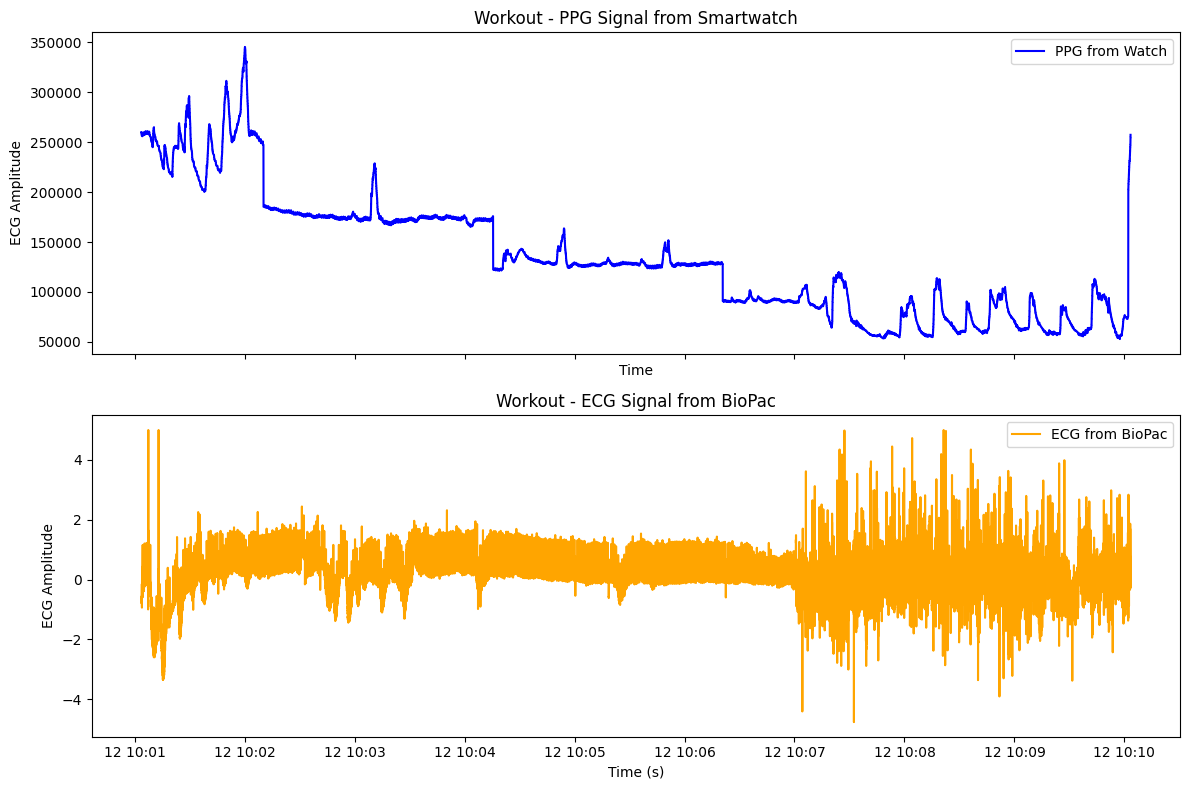

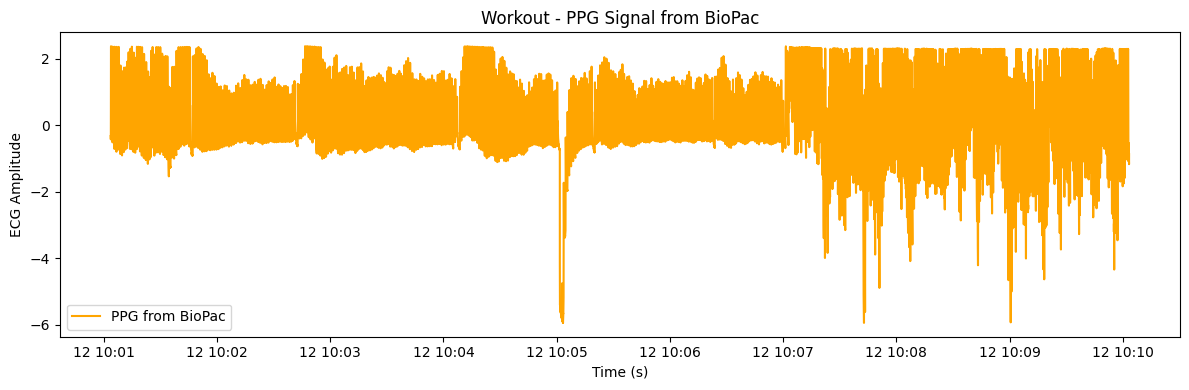

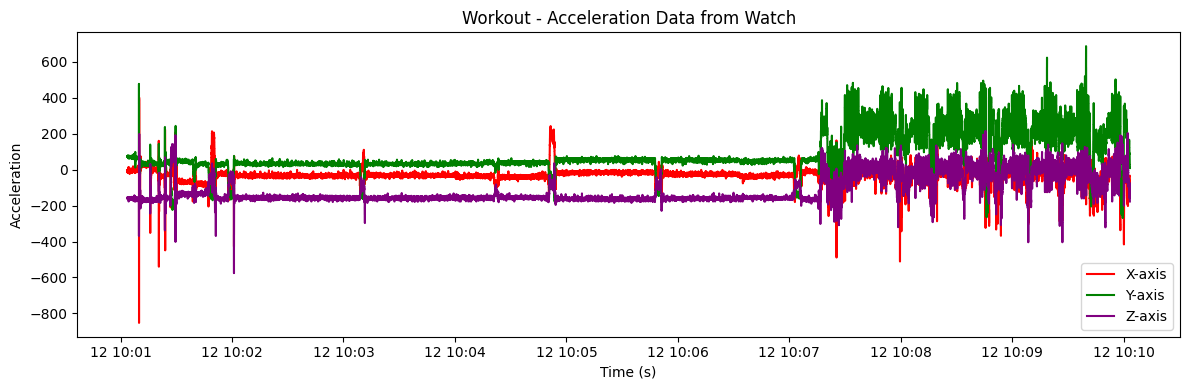

In [16]:
# Q1
plot_watch_bp_ecg(watch_stairs, bp_stairs,
                  start_time=datetime(2025, 6, 12, 10, 1, 3, 334000 ),
                  end_time=datetime(2025, 6, 12, 10, 10, 3, 334000 ),
                  dataset_name='Workout')

In [17]:
# Q1


watch_workout


,timestamp,ecg,PPG,X,Y,Z
0,2025-06-12 10:42:29.360406006,12354,217906,102,-1,288
1,2025-06-12 10:42:29.361406006,12354,217906,102,-1,288
2,2025-06-12 10:42:29.362312988,12357,217906,102,-1,288
3,2025-06-12 10:42:29.363312012,12354,217906,102,-1,288
4,2025-06-12 10:42:29.364312988,12355,217906,102,-1,288
...,...,...,...,...,...,...
567195,2025-06-12 10:51:52.610062988,12354,148105,152,56,235
567196,2025-06-12 10:51:52.611062988,12352,148105,152,56,235
567197,2025-06-12 10:51:52.612062012,14083,148105,152,56,235
567198,2025-06-12 10:51:52.613062988,16761,148105,152,56,235


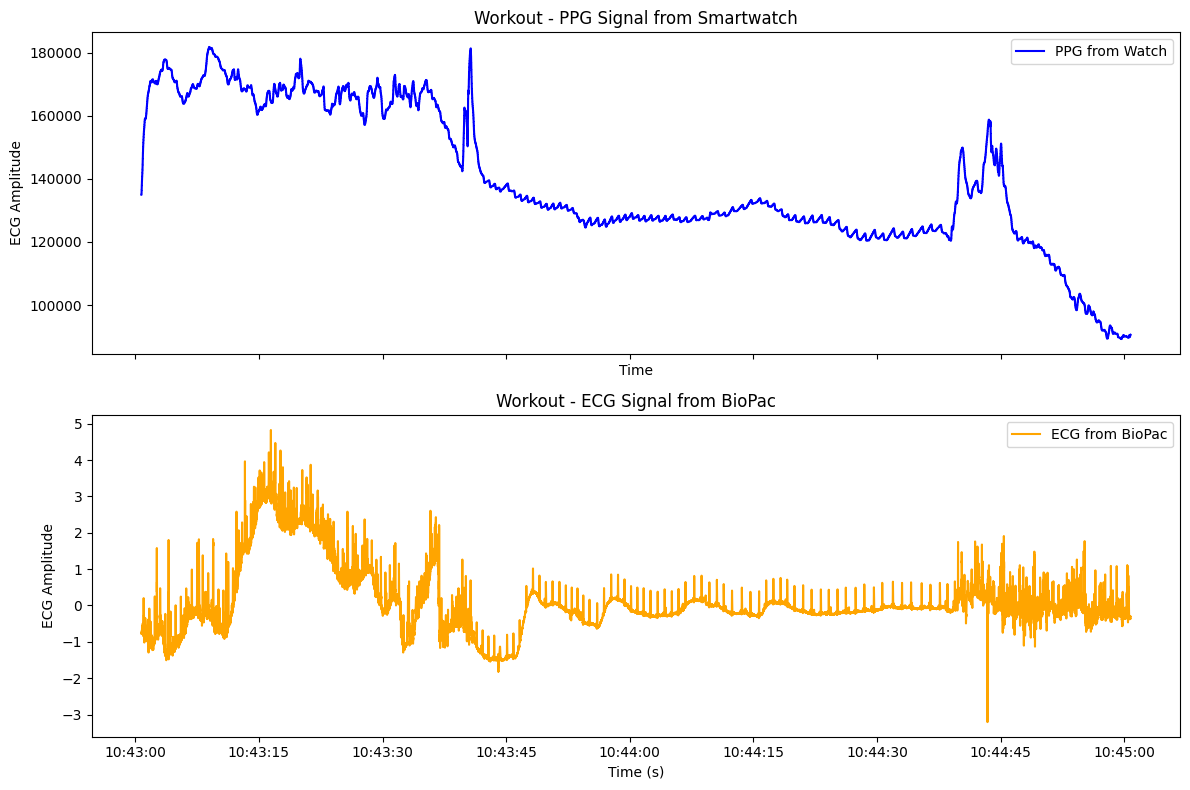

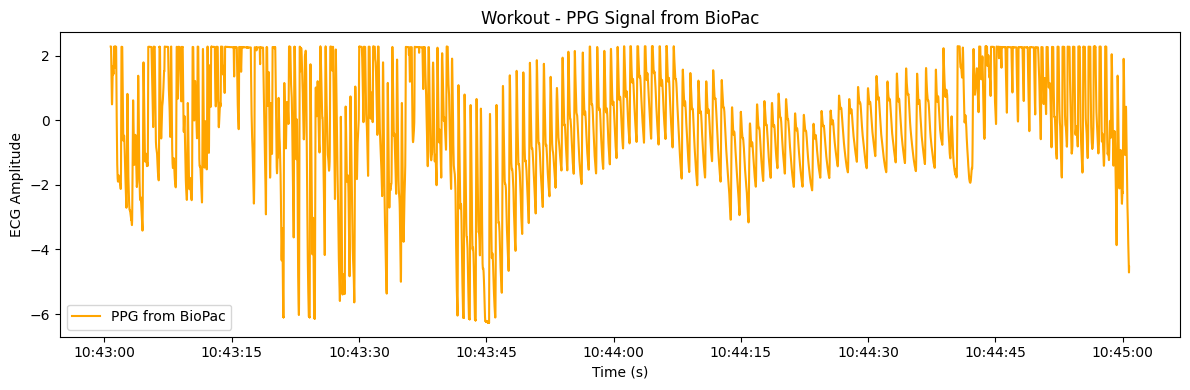

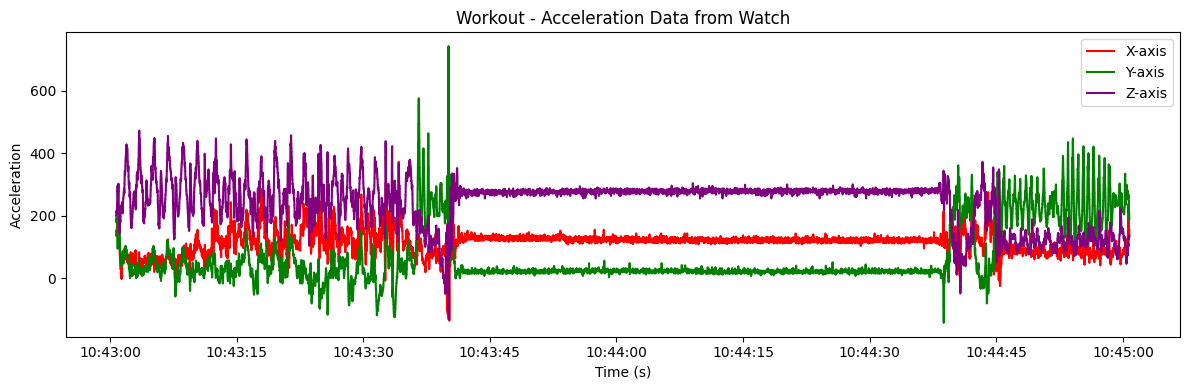

In [18]:
# Q2

plot_watch_bp_ecg(watch_workout, bp_workout,
                  start_time=datetime(2025, 6, 12, 10, 43, 00, 750000),
                  end_time=datetime(2025, 6, 12, 10, 44, 00, 750000) + timedelta(seconds=60),
                  dataset_name='Workout')


In [19]:
# Q3

def compute_heart_rate_metrics(ecg_df, sampling_rate=1000):
    # Schritt 1: R-Peak-Detection mit neurokit2
    ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    rpeaks_indices = rpeaks['ECG_R_Peaks']

    # Schritt 2: Instantane Herzfrequenz (ohne Toolbox)
    rr_intervals = np.diff(ecg_df['timestamp'].values[rpeaks_indices]) / np.timedelta64(1, 's')
    inst_hr = 60 / rr_intervals
    inst_hr_time = ecg_df['timestamp'].values[rpeaks_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': inst_hr_time, 'hr': inst_hr})

    # Schritt 3: Geglättete HR (Median über 10s mit 1s Schrittweite)
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min()
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr = []
    times = []

    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)

        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.median(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_hr_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})

    return inst_hr_df, smoothed_hr_df, ecg_df, rpeaks_indices


def plot_ecg_with_rpeaks(ecg_df, rpeaks_indices, title, start_time, end_time):
    segment = ecg_df[(ecg_df['timestamp'] >= start_time) & (ecg_df['timestamp'] <= end_time)].copy()
    segment_indices = segment.index

    rpeaks_in_segment = [i for i in rpeaks_indices if i in segment_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(segment['timestamp'], segment['ecg'], label='ECG')
    plt.plot(ecg_df['timestamp'].iloc[rpeaks_in_segment],
             ecg_df['ecg'].iloc[rpeaks_in_segment], 'ro', label='R-peaks')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hr(inst_hr_df, smoothed_hr_df, title):
    plt.figure(figsize=(12, 4))
    plt.plot(inst_hr_df['timestamp'], inst_hr_df['hr'], label='Instant HR', alpha=0.7)
    plt.plot(smoothed_hr_df['timestamp'], smoothed_hr_df['smoothed_hr'], label='Smoothed HR', linewidth=2)
    plt.title(title)
    plt.ylabel('Heart Rate (bpm)')
    plt.xlabel('Time')
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\2641998363.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')


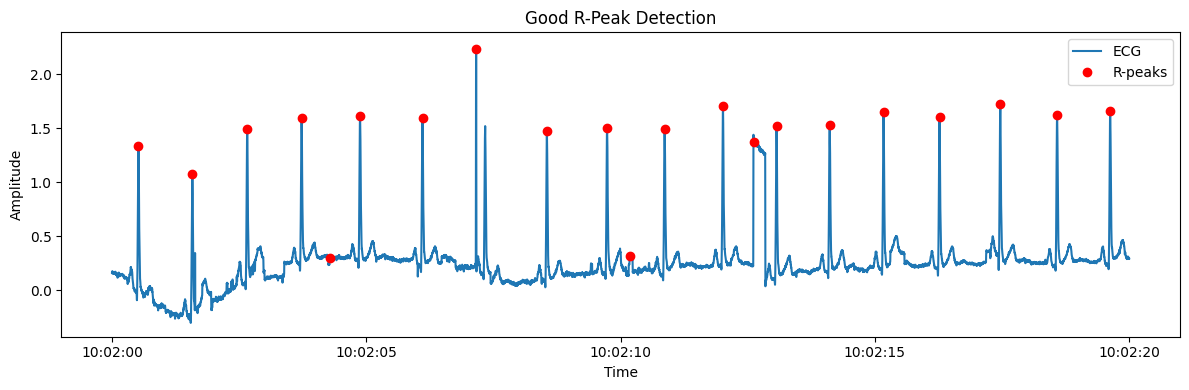

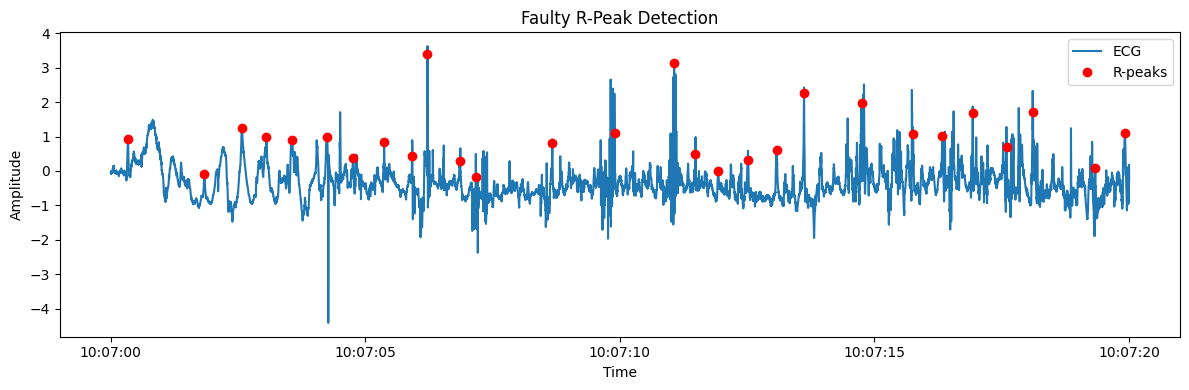

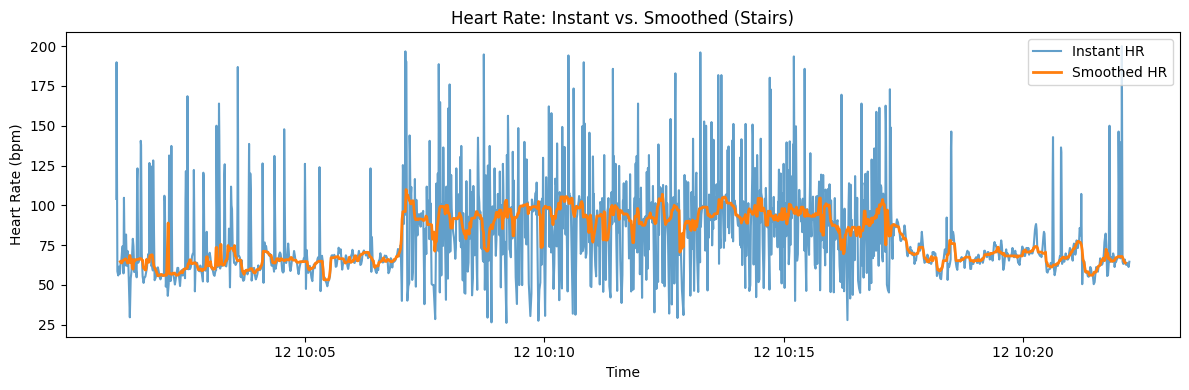

In [20]:
# Q3 
# Schritt 1: Auf eine Biopac-ECG-Messung anwenden (z. B. "Stairs")
inst_hr_df, smoothed_hr_df, ecg_clean_df, rpeaks = compute_heart_rate_metrics(bp_stairs)

# Schritt 2: 20s Segment – wo es gut funktioniert hat (z. B. manuell wählen)
plot_ecg_with_rpeaks(ecg_clean_df, rpeaks,
                     title="Good R-Peak Detection",
                     start_time=datetime(2025, 6, 12, 10, 2, 0),
                     end_time=datetime(2025, 6, 12, 10, 2, 20))

# Schritt 3: 20s Segment – wo es schlecht funktioniert hat (manuell wählen)
plot_ecg_with_rpeaks(ecg_clean_df, rpeaks,
                     title="Faulty R-Peak Detection",
                     start_time=datetime(2025, 6, 12, 10, 7, 0),
                     end_time=datetime(2025, 6, 12, 10, 7, 20))

# Schritt 4: Vergleich der Herzfrequenz-Verläufe
plot_hr(inst_hr_df, smoothed_hr_df, title="Heart Rate: Instant vs. Smoothed (Stairs)")


In [21]:
def compute_heart_rate_metrics_mean(ecg_df, sampling_rate=1000):
    import neurokit2 as nk

    # Schritt 1: R-Peak-Erkennung mit neurokit2
    ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    rpeaks_indices = rpeaks['ECG_R_Peaks']

    # Schritt 2: Instantane Herzfrequenz berechnen (60 / RR-Intervall in s)
    rr_intervals = np.diff(ecg_df['timestamp'].values[rpeaks_indices]) / np.timedelta64(1, 's')
    inst_hr = 60 / rr_intervals
    inst_hr_time = ecg_df['timestamp'].values[rpeaks_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': inst_hr_time, 'hr': inst_hr})

    # Schritt 3: Smoothed HR (Mittelwert über 10s, 1s Schritt)
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min()
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr = []
    times = []

    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)

        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.mean(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_hr_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})

    return inst_hr_df, smoothed_hr_df, ecg_df, rpeaks_indices


C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\1932873525.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')


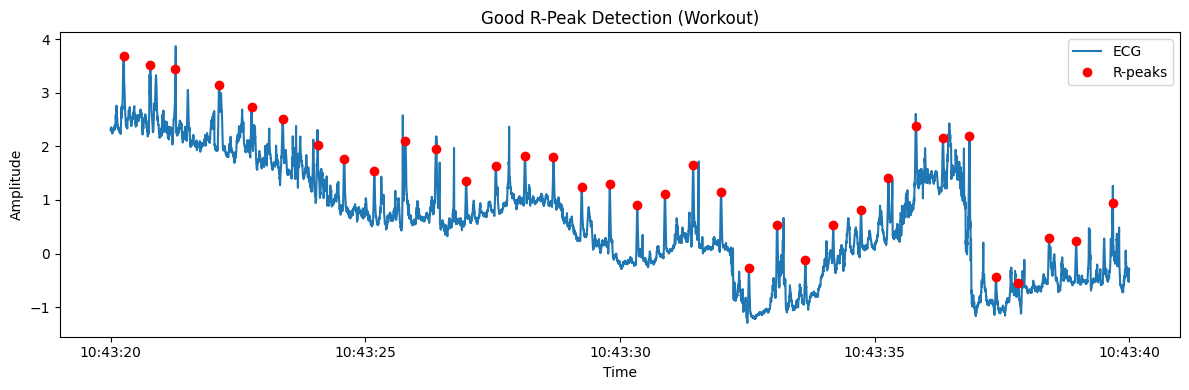

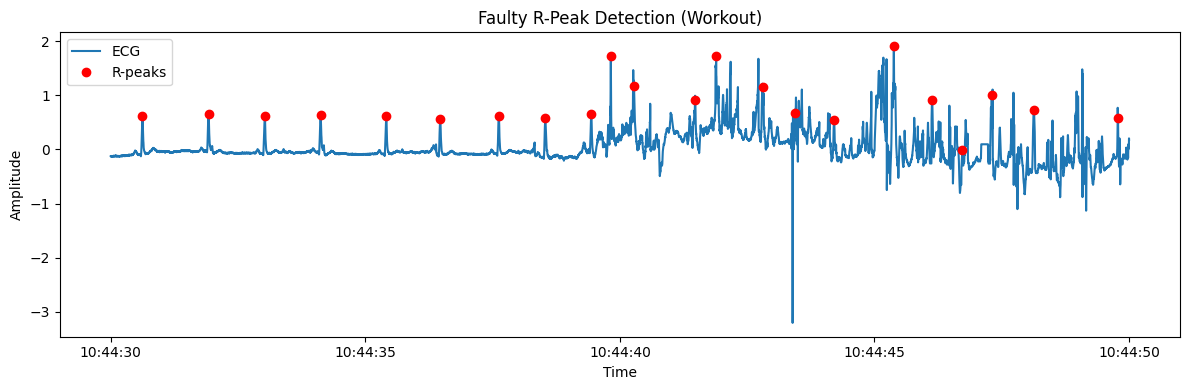

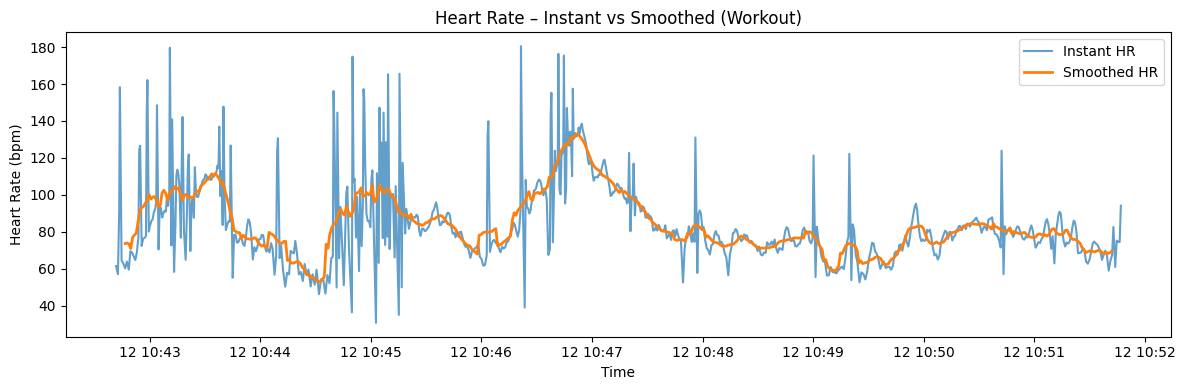

In [22]:
# Q4
# Berechne Herzfrequenzen
inst_hr_df, smoothed_hr_df, ecg_df, rpeaks = compute_heart_rate_metrics_mean(bp_workout)

# Plot: gutes Segment (z. B. 10:43:20–10:43:40)
plot_ecg_with_rpeaks(ecg_df, rpeaks,
                     title="Good R-Peak Detection (Workout)",
                     start_time=datetime(2025, 6, 12, 10, 43, 20),
                     end_time=datetime(2025, 6, 12, 10, 43, 40))

# Plot: schlechtes Segment (z. B. 10:44:30–10:44:50)
plot_ecg_with_rpeaks(ecg_df, rpeaks,
                     title="Faulty R-Peak Detection (Workout)",
                     start_time=datetime(2025, 6, 12, 10, 44, 30),
                     end_time=datetime(2025, 6, 12, 10, 44, 50))

# Plot: Herzfrequenzverlauf
plot_hr(inst_hr_df, smoothed_hr_df, title="Heart Rate – Instant vs Smoothed (Workout)")



In [ ]:
# Q5
def compute_ppg_hr_metrics(ppg_df, sampling_rate=1000):
    import neurokit2 as nk

    ppg_signal = ppg_df['PPG'].fillna(method='ffill').fillna(method='bfill')
    ppg_clean = nk.ppg_clean(ppg_signal, sampling_rate=sampling_rate)
    _, peaks = nk.ppg_peaks(ppg_clean, sampling_rate=sampling_rate)
    peak_indices = peaks['PPG_Peaks']

    # Instantane Herzfrequenz
    timestamps = ppg_df['timestamp'].values
    rr_intervals = np.diff(timestamps[peak_indices]) / np.timedelta64(1, 's')
    hr = 60 / rr_intervals
    hr_time = timestamps[peak_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': hr_time, 'hr': hr})

    # Smoothed HR: Mean in 10s window, 1s slide
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min() + timedelta(seconds=5)
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr, times = [], []
    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)
        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.mean(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})
    return inst_hr_df, smoothed_df, ppg_df, peak_indices

def plot_ppg_with_peaks(ppg_df, peak_indices, title, start_time, end_time):
    segment = ppg_df[(ppg_df['timestamp'] >= start_time) & (ppg_df['timestamp'] <= end_time)]
    segment_indices = segment.index
    peaks_in_segment = [i for i in peak_indices if i in segment_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(segment['timestamp'], segment['PPG'], label='PPG')
    plt.plot(ppg_df['timestamp'].iloc[peaks_in_segment],
             ppg_df['PPG'].iloc[peaks_in_segment], 'ro', label='Peaks')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('PPG Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_ppg_hr(inst_hr_df, smoothed_hr_df, title):
    plt.figure(figsize=(12, 4))
    plt.plot(inst_hr_df['timestamp'], inst_hr_df['hr'], label='Instant HR', alpha=0.6)
    plt.plot(smoothed_hr_df['timestamp'], smoothed_hr_df['smoothed_hr'],
             label='Smoothed HR (10s mean)', linewidth=2)
    plt.title(title)
    plt.ylabel("Heart Rate (bpm)")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()



In [27]:
#Q5

# Herzfrequenz aus Smartwatch-PPG ("Stairs")
inst_hr_ppg, smoothed_hr_ppg, ppg_df, peak_idx = compute_ppg_hr_metrics(watch_stairs)

# Plot: gutes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Good PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 2, 0),
                    end_time=datetime(2025, 6, 12, 10, 2, 20))

# Plot: schlechtes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Faulty PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 4, 0),
                    end_time=datetime(2025, 6, 12, 10, 4, 20))

# Plot: HR-Verlauf
plot_ppg_hr(inst_hr_ppg, smoothed_hr_ppg, title="Smartwatch PPG HR – Instant vs Smoothed (Stairs)")


C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_9292\2229567809.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ppg_signal = ppg_df['PPG'].fillna(method='ffill').fillna(method='bfill')


KeyError: 'ppg'

<Figure size 1200x400 with 0 Axes>

In [25]:
watch_stairs

,timestamp,ecg,PPG,X,Y,Z
0,2025-06-12 10:01:03.670906006,24947,259866,-4,75,-159
1,2025-06-12 10:01:03.671906006,25014,259866,-4,75,-159
2,2025-06-12 10:01:03.672812988,25075,259866,-4,75,-159
3,2025-06-12 10:01:03.673812012,25123,259866,-4,75,-159
4,2025-06-12 10:01:03.674812988,25155,259866,-4,75,-159
...,...,...,...,...,...,...
1301935,2025-06-12 10:22:36.488187012,43201,87336,-16,80,-157
1301936,2025-06-12 10:22:36.489187988,45802,87336,-16,80,-157
1301937,2025-06-12 10:22:36.490187012,49607,87336,-16,80,-157
1301938,2025-06-12 10:22:36.491093994,53984,87336,-16,80,-157


In [ ]:
# Q6



In [ ]:
# Q7



In [ ]:
# Q8



In [ ]:
# Q9

